# Week 2 - Day 4 - Hands On Lab
Univariate EDA on a Real Dataset (Medical Insurance Charges)

### Objective

In this notebook I perform univariate exploratory data analysis on a real dataset - medical insurance charges. I will:

- Visualize the distribution of each numeric variable with histograms
- Use box plots to spot outliers visually
- Apply the IQR method in code to flag outliers precisely
- Check categorical variables for class imbalance with count plots

Dataset: Medical Cost Personal Dataset (Kaggle) - data/insurance.csv, 1,338 records (1 duplicate removed, same as Day 1).

---

**Import Libraries**

In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

---

**Load and Prepare the Data**

In [76]:
df = pd.read_csv("data/insurance.csv")
df = df.drop_duplicates()   # removing the one duplicate row found in Day 1

print("Shape:", df.shape)
print("\nNumeric columns:", df.select_dtypes(include=np.number).columns.tolist())
print("Categorical columns:", df.select_dtypes(include="object").columns.tolist())

df.head()

Shape: (1337, 7)

Numeric columns: ['age', 'bmi', 'children', 'charges']
Categorical columns: ['sex', 'smoker', 'region']


C:\Users\user\AppData\Local\Temp\ipykernel_8560\1339369272.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categorical columns:", df.select_dtypes(include="object").columns.tolist())


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---

**Step 1: Histograms for Numeric Variables**

I'll look at the shape of each numeric column: age, bmi, children, and charges.

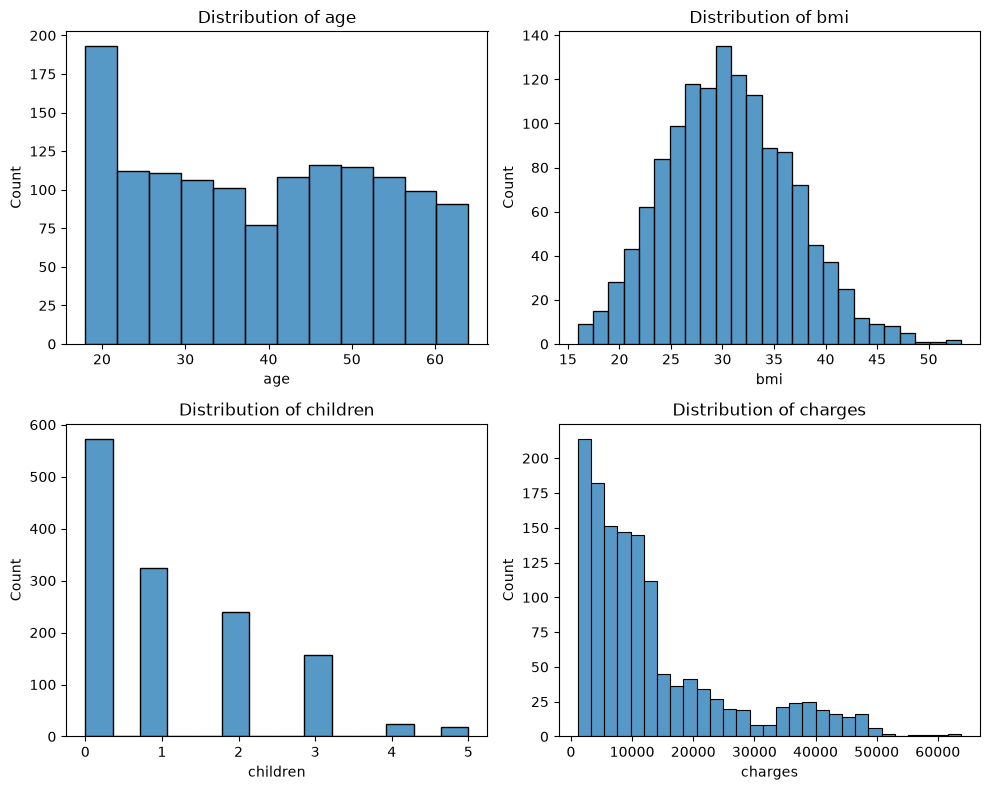

In [77]:
numeric_cols = ["age", "bmi", "children", "charges"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(data=df, x=col, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

**What this shows:**

age and bmi look roughly bell shaped. children is mostly 0-2 with a long thin tail up to 5 - it behaves more like a count variable than a continuous one. charges is heavily right-skewed - most people pay relatively little, but there's a long tail of very expensive cases, matching what I found comparing mean vs. median back in Day 1.

---

**Step 2: Box Plots for Key Numeric Variables**

I'll check age, bmi, and charges specifically for visible outliers (children isn't as useful here since it only takes values 0-5).

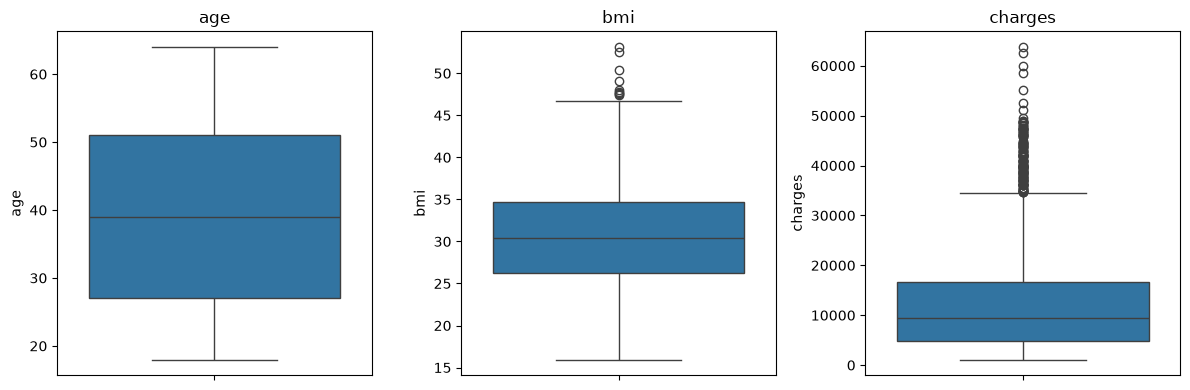

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["age", "bmi", "charges"]):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**What this shows:**
 
age has no visible outliers - the box and whiskers cover the range cleanly. bmi has a few points above the upper whisker. charges has by far the most outliers - a cluster of points well above the upper whisker, confirming the skew from Step 1.

---

**Step 3: IQR Method to Flag Outliers in charges**

In [79]:
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["charges"] < lower_bound) | (df["charges"] > upper_bound)]

print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR)
print("Lower bound:", lower_bound, "Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))
print(outliers["smoker"].value_counts())

Q1: 4746.344 Q3: 16657.71745 IQR: 11911.37345
Lower bound: -13120.716174999998 Upper bound: 34524.777625
Number of outliers: 139
smoker
yes    136
no       3
Name: count, dtype: int64


**Finding:**

 139 rows (about 10%) are flagged as outliers in charges. The striking part: 136 of these 139 (98%) are smokers - even though smokers are only about 20% of the whole dataset. This means the outliers aren't random noise - they're a real pattern: smoking is strongly linked to very high medical costs.

**Decision:**
 I'm keeping these outliers rather than removing them. Deleting them would throw away one of the most important signals in the data - smoker status is clearly something any model on this data needs to account for.

---

**Step 4: Count Plots for Categorical Variables**

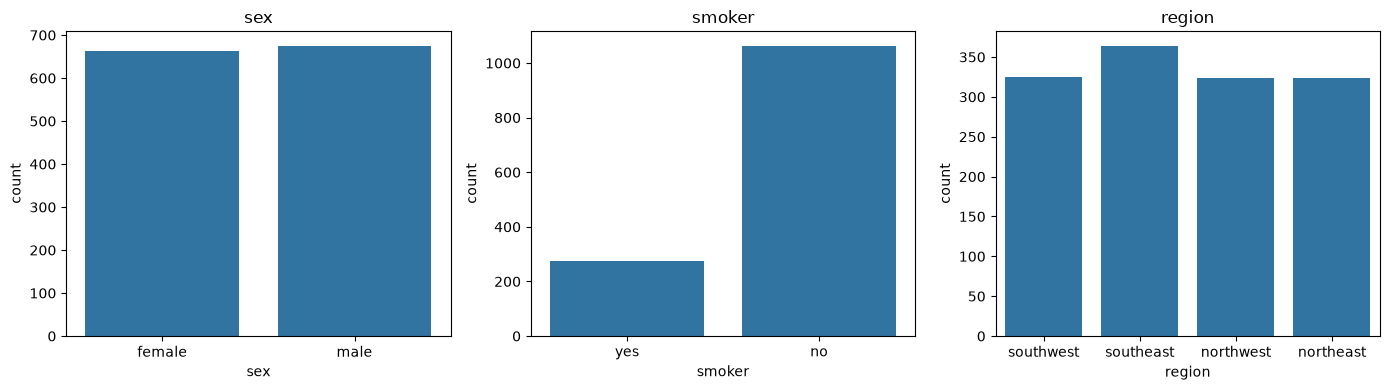

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


In [80]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["sex", "smoker", "region"]):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

print(df["sex"].value_counts())
print(df["smoker"].value_counts())
print(df["region"].value_counts())

**What this shows:**

 sex and region are both fairly balanced - no category dominates. smoker is clearly imbalanced (about 80% non-smokers, 20% smokers) - which, combined with Step 3, means a relatively small group (smokers) is responsible for most of the extreme charges in the dataset.

---

**Summary**

Across all four steps, one theme kept showing up: charges is skewed, has real outliers, and those outliers are almost entirely smokers. Even though smoker itself is an imbalanced category (only 20% of the data), it appears to be the strongest driver of the patterns I found in the numeric distributions. This is the kind of connection EDA is meant to surface before any modeling starts.